# 02 - UNetV2: sampling dynamics and conditioning

A trained denoiser defines more than a mapping from sketch to photograph. Together with a sampler, it defines a family of trajectories whose endpoints depend on both the sketch and the initial noise. This notebook examines that dependence using the epoch-12 EMA weights of UNetV2 from notebook 03.

The experiments use four fixed validation pairs at $256\times256$ and deterministic 60-step DDIM sampling. Varying the noise at a fixed sketch probes the conditional variation; varying the sketch at fixed noise probes the spatial response of the same learned denoising process.

## Selected portraits

The opening gallery contains validation pairs **5, 10 and 15**, selected visually from the 16-pair comparison in notebook 05. These examples illustrate favorable reconstructions rather than an average over the validation set. Each uses its own initial noise; the controlled experiments below use the first four validation pairs.

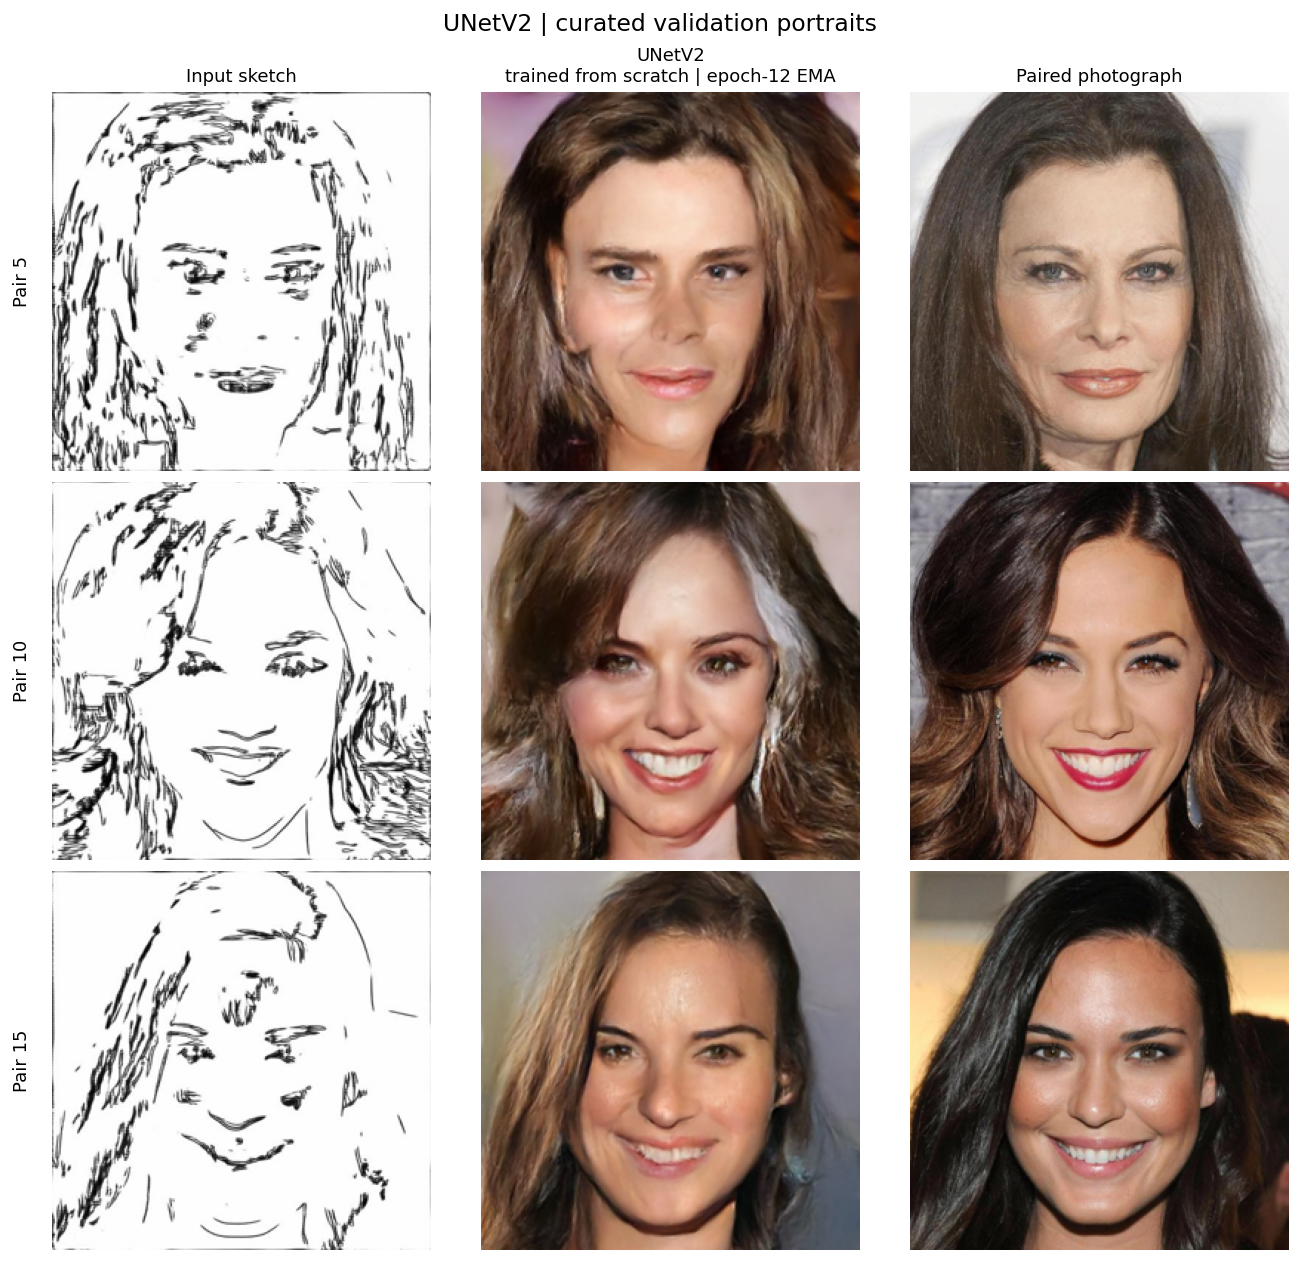

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from base64 import b64encode
from IPython.display import HTML, display
from PIL import Image as PILImage, ImageDraw
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 72

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from models.diffusion import Diffusion
from models.unet_v2 import UNetV2
from utils.data import denormalize, make_dataloader
from utils.visualization import show_forward_diffusion, show_image_rows

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_dir = ROOT / "outputs/unet_v2_exploration"
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
checkpoint = torch.load(
    ROOT / "checkpoints/diffusion_sketch_faces_v2.pt",
    map_location="cpu", weights_only=True,
)
model = UNetV2(**checkpoint["model_args"]).to(device)
model.load_state_dict(checkpoint["ema"])
model.eval()
epoch = checkpoint["epoch"]
del checkpoint
diffusion = Diffusion(timesteps=1000, device=device, schedule="cosine")

loader = make_dataloader(
    ROOT / "data/processed/pairs.csv", split="val", image_size=256,
    batch_size=4, max_items=4, shuffle=False, num_workers=0,
    random_transform=False,
)
sketches, photos = next(iter(loader))
pair_keys = [
    (r["dataset"], Path(r["sketch_path"]).name, Path(r["photo_path"]).name)
    for r in loader.dataset.rows
]
print(f"UNetV2 | epoch {epoch}, EMA | {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")
print(f"Validation: {len(sketches)} pairs at 256 x 256")
print("Sampling: DDIM, 60 steps, eta=0")

UNetV2 | epoch 12, EMA | 41.48M parameters
Validation: 4 pairs at 256 x 256
Sampling: DDIM, 60 steps, eta=0


## Signal and noise in the forward process

At level $t$, the corrupted photograph is

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad \epsilon\sim\mathcal N(0,I).$$

The schedule-dependent signal-to-noise ratio is $\operatorname{SNR}(t)=\bar\alpha_t/(1-\bar\alpha_t)$. At high SNR, denoising mainly concerns local perturbations around visible image structure. At low SNR, the observation provides little photographic information, increasing the importance of the sketch and the learned image distribution.

The panel evaluates the forward marginal at several noise levels with a shared $\epsilon$, isolating the effect of the changing signal and noise coefficients.

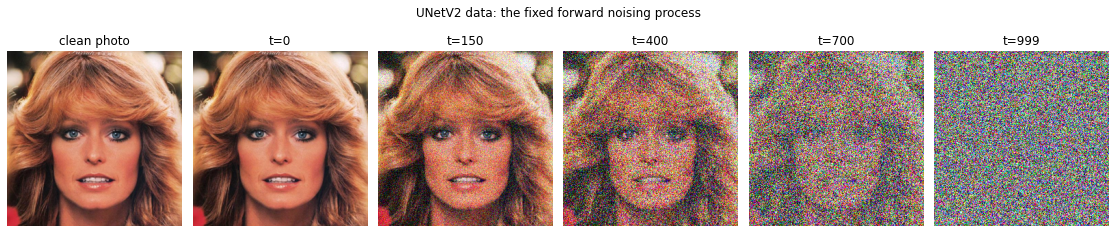

In [3]:
forward_noise = torch.randn(
    1, 3, 256, 256, generator=torch.Generator().manual_seed(456),
)
fig = show_forward_diffusion(
    diffusion, photos, steps=(0, 150, 400, 700, 999), noise=forward_noise,
)
fig.suptitle("UNetV2 data: the fixed forward noising process", y=1.15)
fig.savefig(output_dir / "forward_diffusion.png", dpi=120, bbox_inches="tight")
plt.show()

## Reverse trajectory under DDIM

For velocity prediction, the denoiser determines a clean-image estimate and a noise estimate at each state:

$$\hat x_0=\sqrt{\bar\alpha_t}\,x_t-\sqrt{1-\bar\alpha_t}\,v_\theta,
\qquad
\hat\epsilon=\sqrt{1-\bar\alpha_t}\,x_t+\sqrt{\bar\alpha_t}\,v_\theta.$$

Deterministic DDIM recombines them at the next, lower noise level $u$:

$$x_u=\sqrt{\bar\alpha_u}\,\hat x_0+\sqrt{1-\bar\alpha_u}\,\hat\epsilon.$$

The implemented sampler clips the clean-image estimate before recombination. Although each transition uses an estimate of $x_0$, the displayed frames are the evolving sample states $x_u$. Their residual noise decreases along the trajectory, while subsequent denoiser evaluations can still revise facial structure.

The panel and animation follow the first validation sketch from a Gaussian initialization with seed 123. The same initialization is reused for the other sketches in the conditioning experiments.

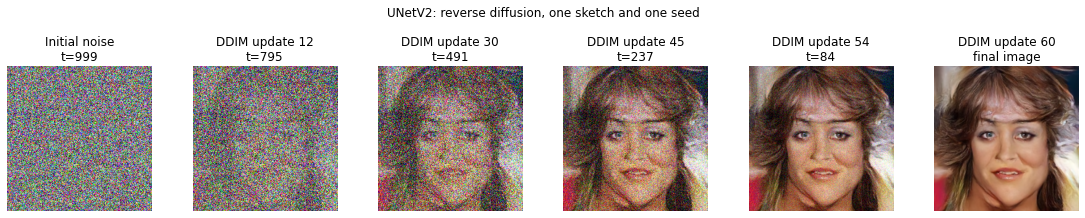

In [4]:
initial_noise = torch.randn(
    1, 3, 256, 256, generator=torch.Generator().manual_seed(123),
).to(device)
generated = []
for i, sketch in enumerate(tqdm(sketches, desc="UNetV2: fixed-noise sketches")):
    result = diffusion.ddim_sample(
        model, sketch[None].to(device), steps=60, eta=0.0,
        noise=initial_noise.clone(), return_intermediates=(i == 0),
    )
    if i == 0:
        image, trajectory = result
    else:
        image = result
    generated.append(image.cpu()[0])
generated = torch.stack(generated)

states = [initial_noise.cpu()[0]] + [image[0] for _, image in trajectory]
frame_labels = ["Initial noise | t=999"] + [
    f"DDIM update {i + 1} | t={t}" for i, (t, _) in enumerate(trajectory)
]
frame_labels[-1] = "DDIM update 60 | final image"
picks = [0, 12, 30, 45, 54, 60]
fig = show_image_rows([[states[i] for i in picks]], [frame_labels[i].replace(" | ", "\n") for i in picks])
fig.suptitle("UNetV2: reverse diffusion, one sketch and one seed", y=1.15)
fig.savefig(output_dir / "reverse_diffusion.png", dpi=120, bbox_inches="tight")
plt.show()


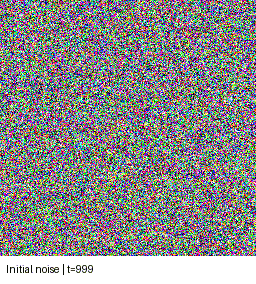

In [5]:
frames = []
for state, label in zip(states[::2], frame_labels[::2]):
    pixels = (denormalize(state).permute(1, 2, 0).numpy() * 255).round().astype("uint8")
    frame = PILImage.new("RGB", (256, 284), "white")
    frame.paste(PILImage.fromarray(pixels), (0, 0))
    ImageDraw.Draw(frame).text((6, 263), label, fill="black")
    frames.append(frame)
frames[0].save(
    output_dir / "reverse_diffusion.gif", save_all=True, append_images=frames[1:],
    duration=[700] + [200] * (len(frames) - 2) + [1400], loop=0,
)
gif = b64encode((output_dir / "reverse_diffusion.gif").read_bytes()).decode()
display(HTML(f'<img src="data:image/gif;base64,{gif}" alt="UNetV2 reverse diffusion" width="256">'))

## Variation at a fixed sketch

With $\eta=0$, the complete sampler can be written as $\hat x_0=G_\theta(s,\xi)$, where $\xi\sim\mathcal N(0,I)$ is the initial noise. Holding $s$ fixed and changing $\xi$ samples different completions of the same sketch.

The four seeds below change color and texture, but also expression and facial proportions. The latter variation indicates that the sketch does not fully constrain the generated geometry. This distinguishes conditional diversity from a stronger, unestablished claim that noise controls appearance independently of structure.

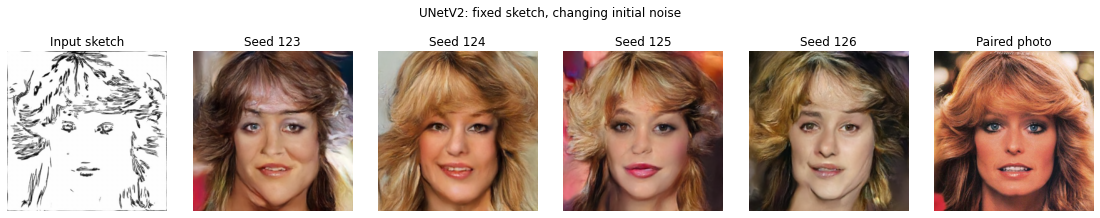

In [6]:
seed_outputs = [generated[0]]
for seed in tqdm([124, 125, 126], desc="UNetV2: different noise seeds"):
    noise = torch.randn(1, 3, 256, 256, generator=torch.Generator().manual_seed(seed)).to(device)
    image = diffusion.ddim_sample(
        model, sketches[:1].to(device), steps=60, eta=0.0, noise=noise,
    )
    seed_outputs.append(image.cpu()[0])
seed_outputs = torch.stack(seed_outputs)
fig = show_image_rows(
    [[sketches[0], *seed_outputs, photos[0]]],
    ["Input sketch", "Seed 123", "Seed 124", "Seed 125", "Seed 126", "Paired photo"],
)
fig.suptitle("UNetV2: fixed sketch, changing initial noise", y=1.15)
fig.savefig(output_dir / "seed_variation.png", dpi=120, bbox_inches="tight")
plt.show()

## Variation at fixed initial noise

The complementary experiment compares $G_\theta(s_i,\xi)$ for four sketches and a shared $\xi$. The sampler and noise are held constant, leaving sketch content as the changing input. Correspondence in head outline, hair and facial landmarks can therefore be examined without variation from independently sampled initial states.

Shared noise provides a controlled comparison, not a shared identity or appearance code: the sketch influences the entire nonlinear denoising trajectory.

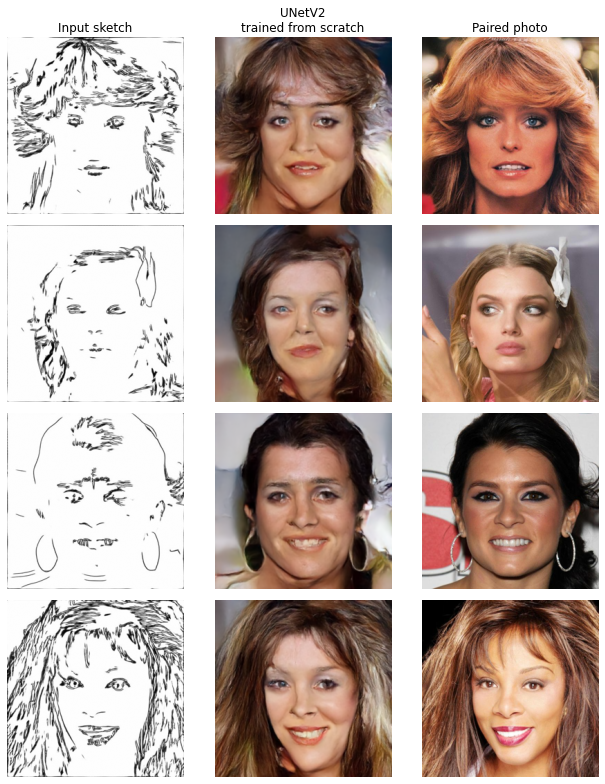

In [7]:
fig = show_image_rows(
    [[sketch, image, photo] for sketch, image, photo in zip(sketches, generated, photos)],
    ["Input sketch", "UNetV2\ntrained from scratch", "Paired photo"],
    figsize=(9, 11),
)
fig.savefig(output_dir / "same_noise_different_sketches.png", dpi=120, bbox_inches="tight")
plt.show()

## Response to conditioning perturbations

For each reference photograph, three outputs are compared: the matched sketch, a cyclically permuted sketch, and a blank white condition. All use the same initial noise. Permutation changes the supplied facial structure while keeping the condition within the observed sketch set; the blank input removes that structure but lies outside the training distribution.

This comparison separates sensitivity to the condition from agreement with the reference. A changed output demonstrates a response to a changed sketch; closer correspondence to the matched photograph is the more relevant evidence of useful conditioning. The blank result is a perturbation diagnostic, not a sample from a separately trained unconditional model.

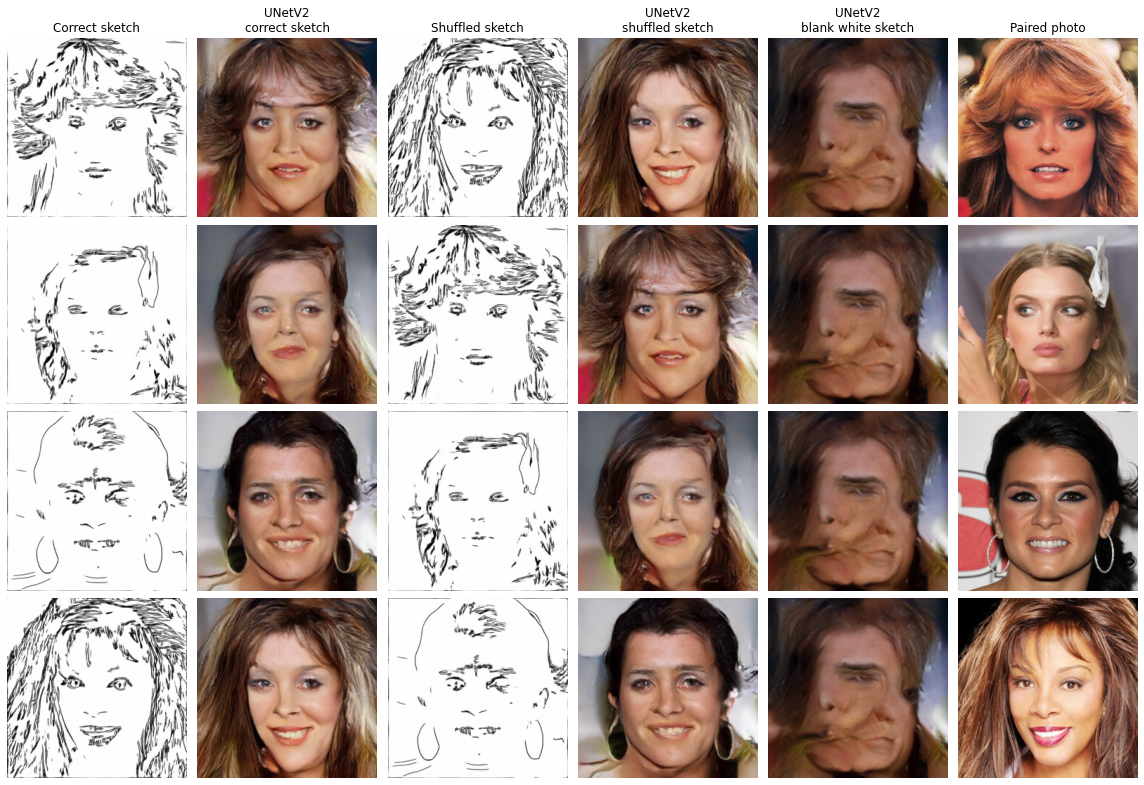

In [8]:
permutation = torch.arange(len(sketches)).roll(1)
shuffled_sketches = sketches[permutation]
shuffled_outputs = generated[permutation]
blank_sketch = torch.ones_like(sketches[:1])
blank_image = diffusion.ddim_sample(
    model, blank_sketch.to(device), steps=60, eta=0.0, noise=initial_noise.clone(),
).cpu()
blank_outputs = blank_image.expand_as(generated)

fig = show_image_rows(
    [[sketches[i], generated[i], shuffled_sketches[i], shuffled_outputs[i],
      blank_outputs[i], photos[i]] for i in range(len(sketches))],
    ["Correct sketch", "UNetV2\ncorrect sketch", "Shuffled sketch",
     "UNetV2\nshuffled sketch", "UNetV2\nblank white sketch", "Paired photo"],
    figsize=(16, 11),
)
fig.savefig(output_dir / "conditioning_check.png", dpi=120, bbox_inches="tight")
plt.show()

### Reference error and conditioning sensitivity

Let $y_i$ be a generated image, $y_i^{\mathrm{matched}}$ the matched-condition output and $x_i$ its reference photograph, all in RGB $[0,1]$. Two quantities summarize the panels:

$$E_i=\frac{\|y_i-x_i\|_1}{3HW},
\qquad \Delta_i=\frac{\|y_i-y_i^{\mathrm{matched}}\|_1}{3HW}.$$

$E_i$ measures reference agreement, whereas $\Delta_i$ measures the magnitude of the conditioning response. In the saved epoch-12 experiment, mean reference MAE is 0.1847 for matched sketches, 0.2362 for permuted sketches and 0.2514 for the blank condition. Matched conditioning has the lowest error on each of the four pairs. This supports sketch-dependent reconstruction on these examples; pixel distances alone do not establish identity preservation.

In [9]:
rows = []
for condition, images in {
    "Correct sketch": generated, "Shuffled sketch": shuffled_outputs, "Blank white sketch": blank_outputs,
}.items():
    pixels = denormalize(images)
    reference_error = (pixels - denormalize(photos)).abs().mean(dim=(1, 2, 3))
    output_change = (pixels - denormalize(generated)).abs().mean(dim=(1, 2, 3))
    for i in range(len(sketches)):
        rows.append(dict(
            pair=i + 1, condition=condition,
            reference_pixel_MAE=reference_error[i].item(),
            change_from_correct_pixel_MAE=output_change[i].item(),
        ))
diagnostics = pd.DataFrame(rows)
display(diagnostics.groupby("condition", sort=False)[
    ["reference_pixel_MAE", "change_from_correct_pixel_MAE"]
].mean().round(4))

,reference_pixel_MAE,change_from_correct_pixel_MAE
condition,,
Correct sketch,0.1847,0.0000
Shuffled sketch,0.2362,0.1410
Blank white sketch,0.2514,0.1589


In [10]:
display(diagnostics.pivot(index="pair", columns="condition", values="reference_pixel_MAE").round(4))
diagnostics.to_csv(output_dir / "conditioning_metrics.csv", index=False)

torch.save(dict(
    model_name="UNetV2", epoch=epoch, weights="EMA", pair_keys=pair_keys,
    sketches=sketches, photos=photos, generated=generated,
    initial_noise=initial_noise.cpu(), trajectory=trajectory,
    seed_outputs=seed_outputs, seeds=[123, 124, 125, 126],
    permutation=permutation, blank_image=blank_image,
    sampling=dict(steps=60, eta=0.0, prediction_type="v", schedule="cosine"),
), output_dir / "exploration.pt")

condition,Blank white sketch,Correct sketch,Shuffled sketch
pair,,,
1,0.2266,0.2051,0.2183
2,0.2770,0.2097,0.2391
3,0.2693,0.1479,0.2294
4,0.2329,0.1760,0.2581
